# Customer Churn Prediction — ML Project
**Role:** Associate Data Analyst | Banking/Telecom Analytics

**Objective:** Predict which customers are likely to churn using historical account,
service, and billing data, so the business can target retention offers proactively.

**Approach:**
1. Exploratory Data Analysis (EDA)
2. Feature engineering & preprocessing
3. Train & compare 3 models: Logistic Regression, Random Forest, XGBoost
4. Evaluate with Accuracy / Precision / Recall / F1 / ROC-AUC
5. Identify top churn drivers (feature importance) → business recommendations

*Dataset: Telco-style customer data (7,043 customers, 20 features) with realistic
correlations between contract type, tenure, billing, and churn — mirroring the
structure of the widely used IBM Telco Customer Churn dataset.*


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
%matplotlib inline


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv("../data/telco_churn.csv")
df.drop(columns=["customerID"], inplace=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

print("Shape:", df.shape)
df.head()


Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,No,No,46,Yes,Yes,Fiber optic,Yes,Yes,No,Yes,No,No,Month-to-month,Yes,Electronic check,100.61,4638.04,Yes
1,Female,1,No,No,60,Yes,No,Fiber optic,Yes,Yes,No,No,No,No,Month-to-month,Yes,Credit card (automatic),95.19,5689.01,No
2,Male,0,No,No,11,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,No,Two year,Yes,Mailed check,101.90,1093.30,Yes
3,Male,0,Yes,Yes,72,Yes,Yes,DSL,Yes,No,No,Yes,No,Yes,One year,Yes,Credit card (automatic),74.11,5296.49,No
4,Male,0,Yes,No,12,Yes,No,Fiber optic,No,Yes,Yes,Yes,No,No,Month-to-month,Yes,Credit card (automatic),108.50,1261.58,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [4]:
print("Missing values:", df.isnull().sum().sum())
print("\nChurn rate:")
df["Churn"].value_counts(normalize=True)


Missing values: 0

Churn rate:


Churn
No     0.640778
Yes    0.359222
Name: proportion, dtype: float64

## 2. Exploratory Data Analysis

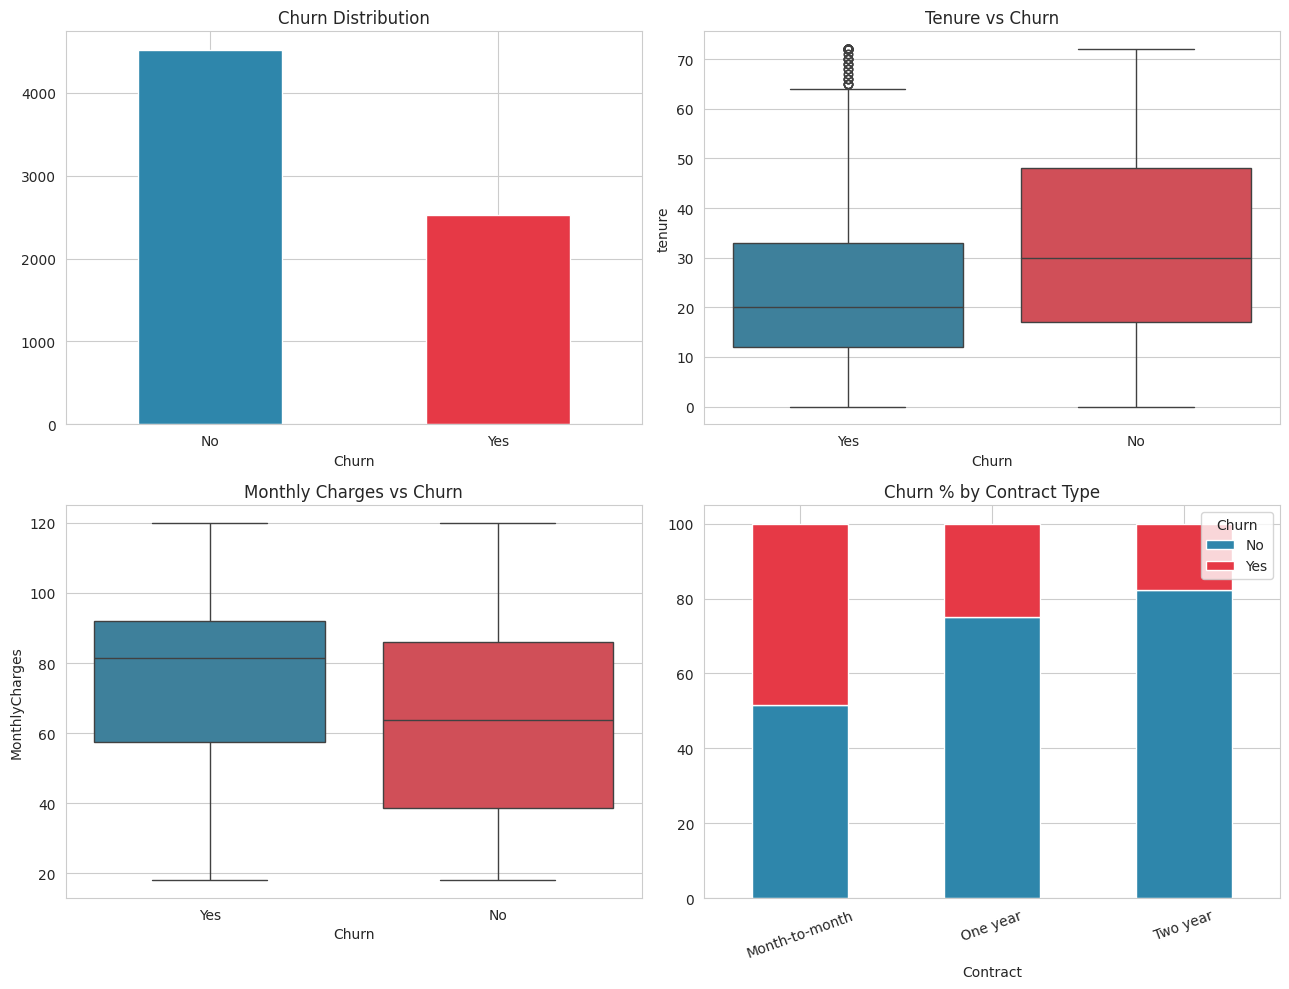

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

df["Churn"].value_counts().plot(kind="bar", ax=axes[0,0], color=["#2E86AB","#E63946"])
axes[0,0].set_title("Churn Distribution")
axes[0,0].set_xticklabels(["No", "Yes"], rotation=0)

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0,1], palette=["#2E86AB","#E63946"])
axes[0,1].set_title("Tenure vs Churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1,0], palette=["#2E86AB","#E63946"])
axes[1,0].set_title("Monthly Charges vs Churn")

churn_by_contract = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
churn_by_contract.plot(kind="bar", stacked=True, ax=axes[1,1], color=["#2E86AB","#E63946"])
axes[1,1].set_title("Churn % by Contract Type")
axes[1,1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


**Key observations:**
- Customers who churn have noticeably **shorter tenure** and are more likely on **month-to-month contracts**.
- **Fiber optic / high monthly charges** customers churn more — possibly price sensitivity or service issues.
- Two-year contract customers rarely churn — loyalty programs / contract locks reduce risk.


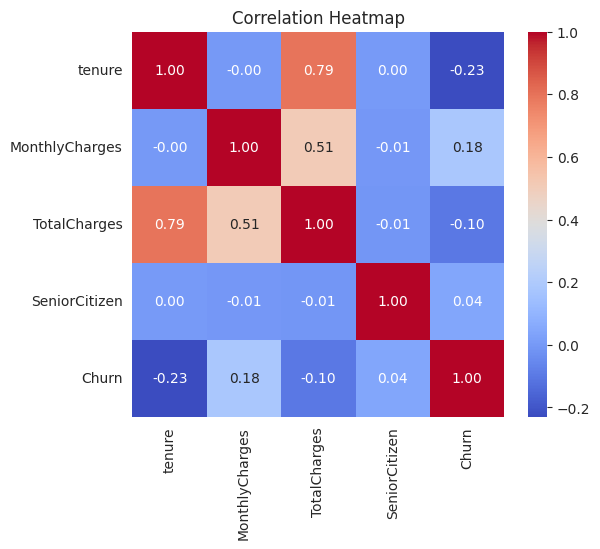

In [6]:
plt.figure(figsize=(6,5))
num_df = df[["tenure","MonthlyCharges","TotalCharges","SeniorCitizen"]].copy()
num_df["Churn"] = (df["Churn"]=="Yes").astype(int)
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## 3. Feature Engineering & Preprocessing

In [7]:
data = df.copy()
data["Churn"] = (data["Churn"] == "Yes").astype(int)

# Engineered features
data["AvgMonthlySpend"] = data["TotalCharges"] / data["tenure"].replace(0, 1)
data["IsNewCustomer"] = (data["tenure"] <= 6).astype(int)
data["NumAddOnServices"] = (
    (data["OnlineSecurity"]=="Yes").astype(int) +
    (data["OnlineBackup"]=="Yes").astype(int) +
    (data["DeviceProtection"]=="Yes").astype(int) +
    (data["TechSupport"]=="Yes").astype(int) +
    (data["StreamingTV"]=="Yes").astype(int) +
    (data["StreamingMovies"]=="Yes").astype(int)
)

cat_cols = data.select_dtypes(include="object").columns.tolist()
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    data[c] = le.fit_transform(data[c])
    encoders[c] = le

X = data.drop(columns=["Churn"])
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (5634, 22)  Test size: (1409, 22)


## 4. Model Training — Logistic Regression, Random Forest, XGBoost

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        eval_metric="logloss", random_state=42
    ),
}

results = {}
roc_data = {}
trained_models = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:,1]

    results[name] = {
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4),
    }
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, results[name]["ROC-AUC"])
    trained_models[name] = model

results_df = pd.DataFrame(results).T
results_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.6969,0.5598,0.7312,0.6341,0.7735
Random Forest,0.6991,0.5674,0.6818,0.6194,0.7749
XGBoost,0.6884,0.5526,0.6957,0.6159,0.7643


## 5. Model Comparison — ROC Curves

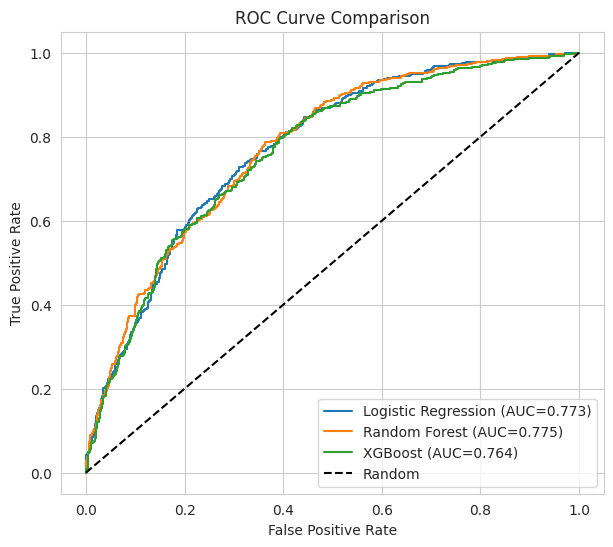

In [9]:
plt.figure(figsize=(7,6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


## 6. Best Model — Confusion Matrix & Classification Report

Best model: Random Forest
              precision    recall  f1-score   support

    No Churn       0.80      0.71      0.75       903
       Churn       0.57      0.68      0.62       506

    accuracy                           0.70      1409
   macro avg       0.68      0.70      0.69      1409
weighted avg       0.72      0.70      0.70      1409



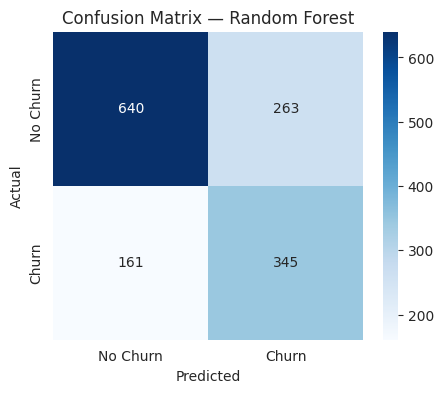

In [10]:
best_name = results_df["ROC-AUC"].astype(float).idxmax()
best_model = trained_models[best_name]
print("Best model:", best_name)

y_pred_best = best_model.predict(X_test_scaled) if best_name=="Logistic Regression" else best_model.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names=["No Churn","Churn"]))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn","Churn"], yticklabels=["No Churn","Churn"])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.show()


## 7. Feature Importance — What Drives Churn?

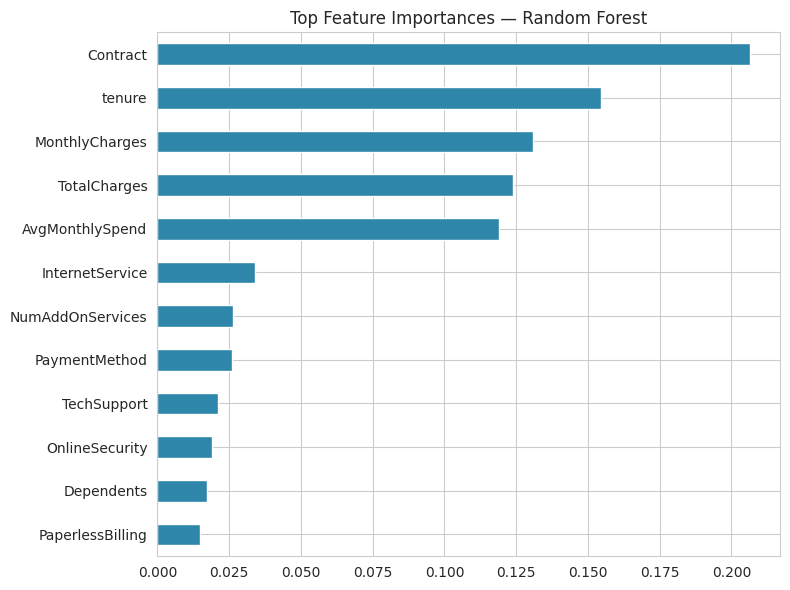

Contract            0.206593
tenure              0.154501
MonthlyCharges      0.130705
TotalCharges        0.124060
AvgMonthlySpend     0.119130
InternetService     0.033915
NumAddOnServices    0.026401
PaymentMethod       0.026093
TechSupport         0.021290
OnlineSecurity      0.018916
dtype: float64

In [11]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
else:
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(12).sort_values().plot(kind="barh", color="#2E86AB")
plt.title(f"Top Feature Importances — {best_name}")
plt.tight_layout()
plt.show()

importances.head(10)


## 8. Business Insights & Recommendations

1. **Contract type is the single biggest churn driver.** Month-to-month customers churn far
   more than 1-/2-year contract holders → push targeted discounts for annual contract upgrades.
2. **Low tenure = high risk.** New customers (<6 months) need an onboarding/engagement journey
   in their first 90 days.
3. **High monthly charges + fiber optic customers** churn more — investigate pricing perception
   or service quality complaints in this segment.
4. **Add-on services (tech support, online security) reduce churn** — bundling these with
   base plans could improve retention.
5. **Actionable output:** the model's `Churn_Probability` score can be used to build a
   prioritized outreach list for the retention/collections team — focus on the top-decile
   risk customers first for maximum ROI on retention spend.

## 9. Next Steps
- Hyperparameter tuning (GridSearchCV / Optuna) for further AUC gains
- SHAP values for per-customer explainability
- Deploy as a scheduled scoring pipeline (batch or API) integrated with CRM
- A/B test retention offers against the model's risk segments
